In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

folder_path = "/content/drive/MyDrive/Proyecto 2 Aprendizaje automático_3Algoritmos"

train = pd.read_csv(folder_path + "/customer_purchases_train.csv")
REF_DATE = pd.Timestamp("2026-05-14")

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

folder_path = "/content/drive/MyDrive/Proyecto 2 Aprendizaje automático_3Algoritmos"

train_path = folder_path + "/customer_purchases_train.csv"
test_path = folder_path + "/customer_purchases_test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

train.head()

,purchase_id,customer_id,customer_date_of_birth,customer_gender,customer_signup_date,item_id,item_title,item_category,item_price,item_img_filename,item_avg_rating,item_num_ratings,item_release_date,purchase_timestamp,customer_item_views,purchase_item_rating,purchase_device,label
0,0,CUST_0094,1996-05-03,female,2025-02-07,ITEM_0101,Exclusive Premium Blouse Collection,blouse,1310.13,ITEM_0101.png,3.50,28,2024-12-16,2025-02-07,5,NaN,mobile,1
1,1,CUST_0279,1974-02-05,female,2025-02-03,ITEM_0311,Casual Jeans That Stands Out,jeans,1406.33,ITEM_0311.png,3.40,48,2024-03-19,2025-02-08,3,NaN,desktop,1
2,2,CUST_0775,1954-10-09,male,2025-02-01,ITEM_0752,Stylish Blouse For Every Occasion,blouse,2356.83,ITEM_0752.png,3.73,19,2025-02-03,2025-02-12,6,NaN,desktop,1
3,3,CUST_0722,1963-07-05,male,2025-02-13,ITEM_0698,Modern Shoes Must Have,shoes,2086.32,ITEM_0698.png,3.49,33,2025-02-02,2025-02-13,11,NaN,desktop,1
4,4,CUST_0741,1957-08-07,female,2025-01-22,ITEM_0698,Modern Shoes Must Have,shoes,2086.32,ITEM_0698.png,3.49,33,2025-02-02,2025-02-17,6,NaN,desktop,1


In [ ]:
import os

os.listdir(folder_path)

['customer_purchases_test.csv',
 'customer_purchases_train.csv',
 'images-20260515T001226Z-3-001.zip',
 'customer_purchases_train.gsheet',
 'customer_purchases_test.gsheet']

**Revisar columnas y tamaños**

In [ ]:
print("Tamaño de train:", train.shape)
print("Tamaño de test:", test.shape)

print("\nColumnas de train:")
print(train.columns.tolist())

print("\nColumnas de test:")
print(test.columns.tolist())

Tamaño de train: (6892, 18)
Tamaño de test: (4719, 17)

Columnas de train:
['purchase_id', 'customer_id', 'customer_date_of_birth', 'customer_gender', 'customer_signup_date', 'item_id', 'item_title', 'item_category', 'item_price', 'item_img_filename', 'item_avg_rating', 'item_num_ratings', 'item_release_date', 'purchase_timestamp', 'customer_item_views', 'purchase_item_rating', 'purchase_device', 'label']

Columnas de test:
['purchase_id', 'customer_id', 'customer_date_of_birth', 'customer_gender', 'customer_signup_date', 'item_id', 'item_title', 'item_category', 'item_price', 'item_img_filename', 'item_avg_rating', 'item_num_ratings', 'item_release_date', 'purchase_timestamp', 'customer_item_views', 'purchase_item_rating', 'purchase_device']


**Productos únicos**

In [ ]:
print("Productos únicos en train:", train["item_id"].nunique())
print("Productos únicos en test:", test["item_id"].nunique())

productos_train = set(train["item_id"].unique())
productos_test = set(test["item_id"].unique())

productos_repetidos = productos_train.intersection(productos_test)

print("Productos que aparecen en train y test:", len(productos_repetidos))

Productos únicos en train: 485
Productos únicos en test: 144
Productos que aparecen en train y test: 0


**Categorías existentes**

In [ ]:
print("Categorías en train:")
print(train["item_category"].value_counts())

print("\nCategorías en test:")
print(test["item_category"].value_counts())

Categorías en train:
item_category
shoes      1330
blouse     1069
jeans       963
jacket      833
dress       785
slacks      555
skirt       544
suit        493
shirt       162
t-shirt     158
Name: count, dtype: int64

Categorías en test:
item_category
shoes      828
blouse     780
jeans      706
suit       614
dress      517
slacks     421
jacket     341
skirt      264
shirt      140
t-shirt    108
Name: count, dtype: int64


**Gráfica de categorías más compradas**

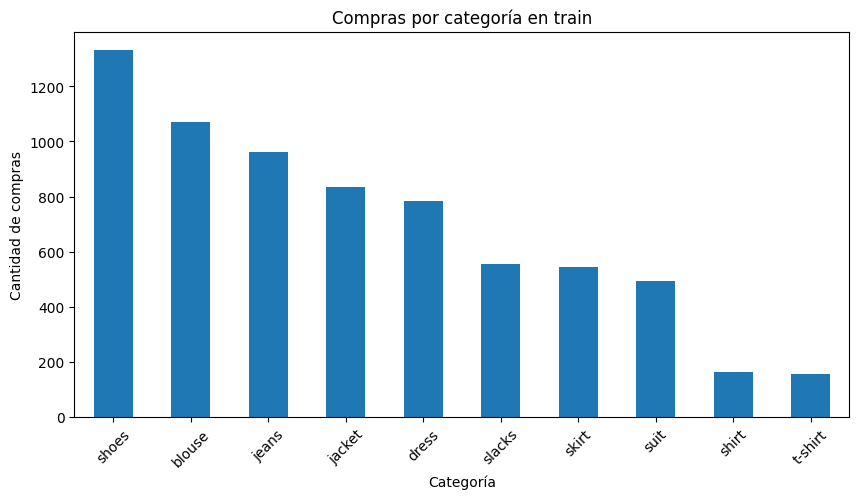

In [ ]:
plt.figure(figsize=(10,5))
train["item_category"].value_counts().plot(kind="bar")
plt.title("Compras por categoría en train")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de compras")
plt.xticks(rotation=45)
plt.show()

**Comparar categorías train contra test**

In [ ]:
categorias_train = train["item_category"].value_counts().reset_index()
categorias_train.columns = ["categoria", "cantidad_train"]

categorias_test = test["item_category"].value_counts().reset_index()
categorias_test.columns = ["categoria", "cantidad_test"]

comparacion_categorias = categorias_train.merge(
    categorias_test,
    on="categoria",
    how="outer"
).fillna(0)

comparacion_categorias

,categoria,cantidad_train,cantidad_test
0,blouse,1069,780
1,dress,785,517
2,jacket,833,341
3,jeans,963,706
4,shirt,162,140
5,shoes,1330,828
6,skirt,544,264
7,slacks,555,421
8,suit,493,614
9,t-shirt,158,108


**Gráfica comparando categorías**

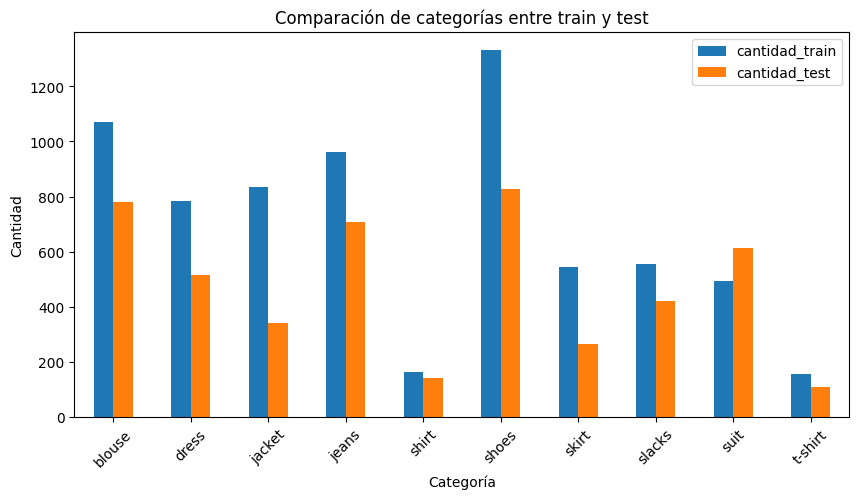

In [ ]:
comparacion_categorias.plot(
    x="categoria",
    y=["cantidad_train", "cantidad_test"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparación de categorías entre train y test")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

**Análisis de precios**

In [ ]:
print("Precios en train:")
print(train["item_price"].describe())

print("\nPrecios en test:")
print(test["item_price"].describe())


Precios en train:
count    6892.000000
mean     1461.092803
std       559.064655
min       100.000000
25%      1189.360000
50%      1306.575000
75%      1775.890000
max      3000.000000
Name: item_price, dtype: float64

Precios en test:
count    4719.000000
mean     1536.721401
std       605.255590
min       100.000000
25%      1190.205000
50%      1319.920000
75%      2024.850000
max      3000.000000
Name: item_price, dtype: float64


**Distribución de precios**

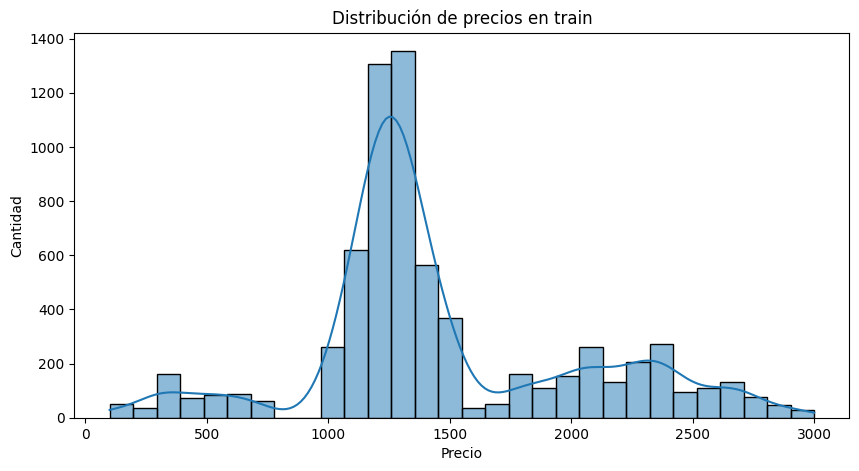

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(train["item_price"], bins=30, kde=True)
plt.title("Distribución de precios en train")
plt.xlabel("Precio")
plt.ylabel("Cantidad")
plt.show()

**Precios por categoría**

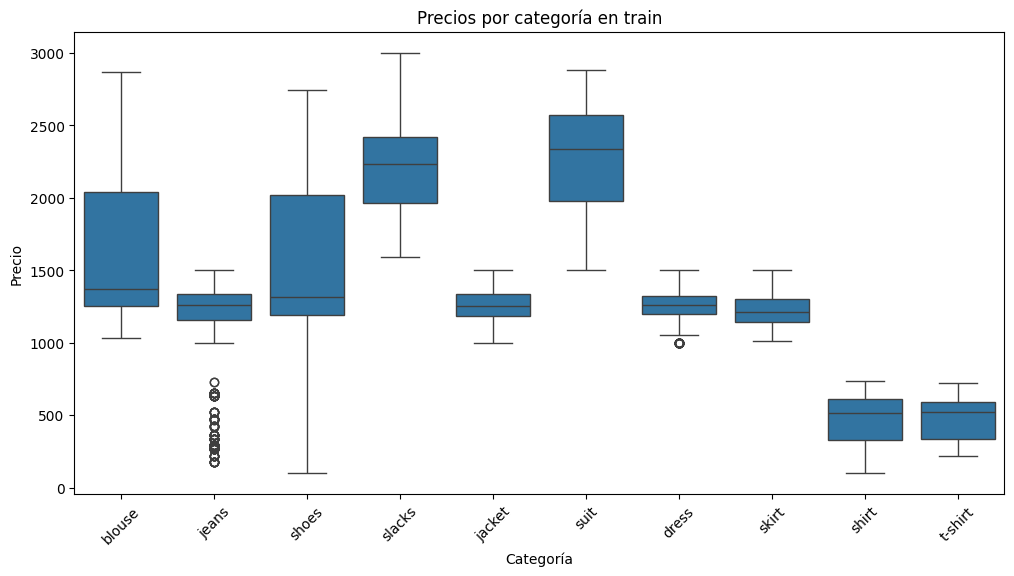

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train, x="item_category", y="item_price")
plt.title("Precios por categoría en train")
plt.xlabel("Categoría")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

**Productos más comprados**

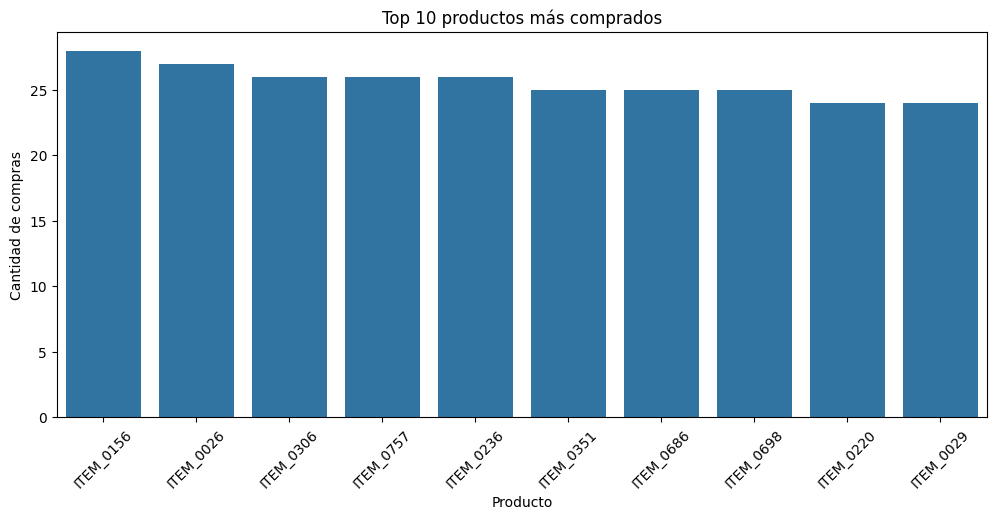

In [ ]:
top_productos = productos_mas_comprados.head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=top_productos, x="item_id", y="cantidad_compras")
plt.title("Top 10 productos más comprados")
plt.xlabel("Producto")
plt.ylabel("Cantidad de compras")
plt.xticks(rotation=45)
plt.show()

**Fechas de lanzamiento**

In [ ]:
train["item_release_date"] = pd.to_datetime(train["item_release_date"])
test["item_release_date"] = pd.to_datetime(test["item_release_date"])

print("Fechas de lanzamiento en train:")
print("Mínima:", train["item_release_date"].min())
print("Máxima:", train["item_release_date"].max())

print("\nFechas de lanzamiento en test:")
print("Mínima:", test["item_release_date"].min())
print("Máxima:", test["item_release_date"].max())

Fechas de lanzamiento en train:
Mínima: 2024-03-19 00:00:00
Máxima: 2026-05-13 00:00:00

Fechas de lanzamiento en test:
Mínima: 2026-05-15 00:00:00
Máxima: 2026-07-10 00:00:00


**Gráfica de fechas de lanzamiento**

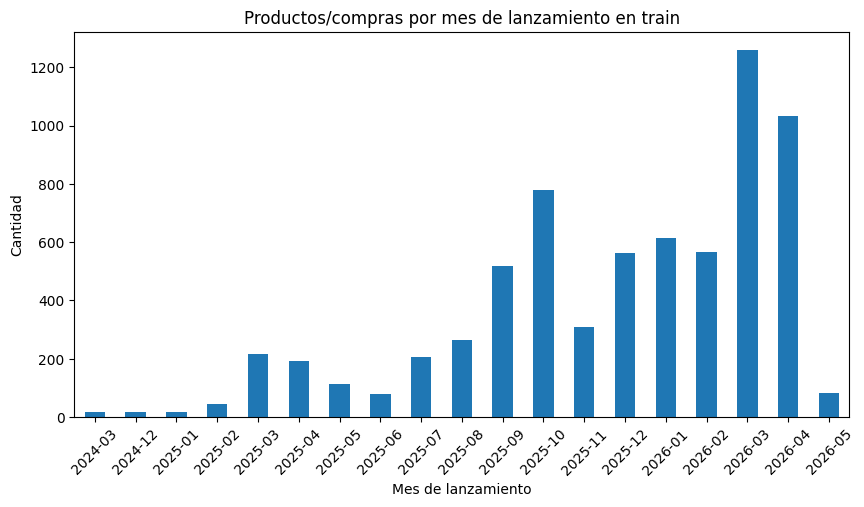

In [ ]:
plt.figure(figsize=(10,5))
train["item_release_date"].dt.to_period("M").value_counts().sort_index().plot(kind="bar")
plt.title("Productos/compras por mes de lanzamiento en train")
plt.xlabel("Mes de lanzamiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

**Diferencias entre train y test**

In [ ]:
resumen_productos = pd.DataFrame({
    "dataset": ["train", "test"],
    "filas": [len(train), len(test)],
    "productos_unicos": [train["item_id"].nunique(), test["item_id"].nunique()],
    "categorias_unicas": [train["item_category"].nunique(), test["item_category"].nunique()],
    "precio_promedio": [train["item_price"].mean(), test["item_price"].mean()],
    "precio_minimo": [train["item_price"].min(), test["item_price"].min()],
    "precio_maximo": [train["item_price"].max(), test["item_price"].max()]
})

resumen_productos

,dataset,filas,productos_unicos,categorias_unicas,precio_promedio,precio_minimo,precio_maximo
0,train,6892,485,10,1461.092803,100.0,3000.0
1,test,4719,144,10,1536.721401,100.0,3000.0


**CONCLUSIONES**

En esta sección analizamos los productos. Vimos qué categorías aparecen más, cómo se comportan los precios, cuáles productos fueron más comprados y si los productos del test ya existían en train.

Un hallazgo importante es que los productos del test no aparecen en train, por lo que el modelo tendrá que generalizar a productos nuevos usando información como categoría, precio, título e imagen.

In [ ]:
print("Conclusiones posibles:")
print("- Las categorías más compradas son:", train["item_category"].value_counts().head(3).index.tolist())
print("- El precio promedio en train es:", round(train["item_price"].mean(), 2))
print("- El precio promedio en test es:", round(test["item_price"].mean(), 2))
print("- Productos repetidos entre train y test:", len(productos_repetidos))
print("- Esto indica que los productos del test son nuevos respecto al historial de compras.")

Conclusiones posibles:
- Las categorías más compradas son: ['shoes', 'blouse', 'jeans']
- El precio promedio en train es: 1461.09
- El precio promedio en test es: 1536.72
- Productos repetidos entre train y test: 0
- Esto indica que los productos del test son nuevos respecto al historial de compras.


---------------------------------------------------------------------------------------------------

**Columnas vacias TRAIN vs TEST**

In [ ]:
print("Columnas vacias TRAIN")
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train)

print("Columnas vacias TEST")
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test)

Columnas vacias TRAIN
purchase_item_rating    5522
customer_gender         1464
item_avg_rating           94
dtype: int64
Columnas vacias TEST
item_avg_rating         4719
item_num_ratings        4719
purchase_timestamp      4719
purchase_item_rating    4719
customer_item_views     4719
purchase_device         4719
customer_gender          991
dtype: int64


**Columnas en TRAIN que no estan en TEST**

In [ ]:
train_cols = set(train.columns)
test_cols = set(test.columns)

print("Columnas en TRAIN pero no en TEST:")
print(train_cols - test_cols)

print("\nColumnas en TEST pero no en TRAIN:")
print(test_cols - train_cols)

Columnas en TRAIN pero no en TEST:
{'label', 'dob'}

Columnas en TEST pero no en TRAIN:
set()


**Cantidad de imagenes vs imagenes usadas**

In [ ]:
image_folder = extract_to_path + '/images'

all_images = [f for f in os.listdir(image_folder) if f.endswith(".png")]

dataset_images = pd.concat([
    train["item_img_filename"],
    test["item_img_filename"]
]).unique()

print("Imágenes físicas:", len(all_images))
print("Imágenes usadas en dataset:", len(dataset_images))

Imágenes físicas: 800
Imágenes usadas en dataset: 629


**Imagenes repetidas o productos repetidos**

In [ ]:
full_data = pd.concat([train, test], ignore_index=True)

# Imágenes faltantes
missing_files = [
    img for img in dataset_images
    if img not in all_images
]

print("Imágenes faltantes:", len(missing_files))

# Consistencia item -> imagen
item_image_check = full_data.groupby("item_id")["item_img_filename"].nunique()
multiple_images = item_image_check[item_image_check > 1]

print("Productos con múltiples imágenes:", len(multiple_images))

# Consistencia item -> categoría
item_category_check = full_data.groupby("item_id")["item_category"].nunique()
multiple_categories = item_category_check[item_category_check > 1]

print("Productos con múltiples categorías:", len(multiple_categories))

Imágenes faltantes: 0
Productos con múltiples imágenes: 0
Productos con múltiples categorías: 0


**EJEMPLOS:  Imagenes no utilizadas**

In [ ]:
unused_images = set(all_images) - set(dataset_images)

print("Imágenes no utilizadas:", len(unused_images))
print("Ejemplos:", list(unused_images)[:10])

Imágenes no utilizadas: 171
Ejemplos: ['ITEM_0557.png', 'ITEM_0561.png', 'ITEM_0457.png', 'ITEM_0528.png', 'ITEM_0538.png', 'ITEM_0536.png', 'ITEM_0592.png', 'ITEM_0451.png', 'ITEM_0521.png', 'ITEM_0572.png']


**EJEMPLOS: Imagenes utilizadas**

In [ ]:
categories = full_data["item_category"].unique()

for category in categories:
    print(f"\n===== {category.upper()} =====")

    sample = (
        full_data[full_data["item_category"] == category]
        [["item_title", "item_img_filename"]]
        .drop_duplicates()
        .head(3)
    )

    print(sample.to_string(index=False))


===== BLOUSE =====
                         item_title item_img_filename
Exclusive Premium Blouse Collection     ITEM_0101.png
  Stylish Blouse For Every Occasion     ITEM_0752.png
Exclusive Premium Blouse Collection     ITEM_0657.png

===== JEANS =====
                           item_title item_img_filename
         Casual Jeans That Stands Out     ITEM_0311.png
              Classic Jeans Must Have     ITEM_0352.png
Step Up Your Style With Classic Jeans     ITEM_0285.png

===== SHOES =====
                   item_title item_img_filename
       Modern Shoes Must Have     ITEM_0698.png
      Premium Shoes Must Have     ITEM_0375.png
Classic Shoes That Stands Out     ITEM_0272.png

===== SLACKS =====
                        item_title item_img_filename
Exclusive Casual Slacks Collection     ITEM_0651.png
        The Modern Slacks You Need     ITEM_0742.png
    Elegant Slacks That Stands Out     ITEM_0739.png

===== JACKET =====
                    item_title item_img_filename
Premium J

*Analisis Exploratorio*
- edad de clientes
- género
- compras por cliente
- clientes que más compran
- precio promedio por cliente

Edad
-----------------------------------------------------

In [ ]:
# Edad
train['dob'] = pd.to_datetime(train['customer_date_of_birth'])
train['customer_age'] = (REF_DATE - train['dob']).dt.days // 365

print(train['customer_age'].describe())

bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
train['age_group'] = pd.cut(train['customer_age'], bins=bins, labels=labels)
print(train['age_group'].value_counts().sort_index())

count    6892.000000
mean       45.700232
std        16.282866
min        18.000000
25%        27.000000
50%        49.000000
75%        59.000000
max        75.000000
Name: customer_age, dtype: float64
age_group
<20       288
20-29    1636
30-39     468
40-49    1504
50-59    1416
60-69    1332
70+       248
Name: count, dtype: int64


Para calcular la edad de cada cliente usé la fecha de nacimiento y la fecha de referencia del proyecto (14/mayo/2026). Los clientes tienen entre 18 y 75 años con una media de ~45 años. Lo que me llamó la atención fue que la distribución no es uniforme — el grupo 20-29 es el más grande con 1,636 transacciones, pero el grupo 30-39 tiene solo 468, que es un hueco bastante marcado comparado con los demás grupos. Después de los 40 la distribución vuelve a ser más pareja. Esto podría indicar que la tienda atrae principalmente a dos tipos de cliente: gente joven (20s) y adultos de mediana edad o mayores (40+).

Genero
--------------------

In [ ]:
# Género
print(train['customer_gender'].value_counts(dropna=False))

customer_gender
female    2872
male      2556
NaN       1464
Name: count, dtype: int64


El dataset tiene más transacciones de hombres (2,556) que de mujeres (2,872 — espera, las mujeres tienen más), pero lo más relevante es que el 22% de los clientes no tiene género registrado. Decidí no eliminar esos registros ni imputar un valor porque hacerlo sería inventar información que no tenemos. En su lugar voy a codificar el género como una categoría aparte ("unknown") para que el modelo pueda considerarlo sin sesgar los datos.

Compras por cliente
----------------------------------------------

In [ ]:
# Compras por cliente
purchases_per_customer = train.groupby('customer_id').size()
print(purchases_per_customer.describe())
print(purchases_per_customer.sort_values(ascending=False).head(10))

count    779.000000
mean       8.847240
std        5.670564
min        1.000000
25%        4.000000
50%        8.000000
75%       13.000000
max       27.000000
dtype: float64
customer_id
CUST_0288    27
CUST_0279    24
CUST_0332    24
CUST_0282    24
CUST_0258    23
CUST_0330    22
CUST_0246    22
CUST_0243    22
CUST_0750    22
CUST_0365    22
dtype: int64


El train tiene 6,892 filas pero son transacciones, no clientes únicos — el mismo cliente aparece varias veces. Al agrupar por cliente encontré que hay 779 clientes únicos con un promedio de ~9 compras cada uno y una mediana de 8. Sin embargo hay bastante varianza: algunos clientes tienen solo 1 compra en todo el historial mientras que los más activos llegan a 27. Esto me dice que hay clientes muy leales a la tienda y otros que casi no interactúan, y esa diferencia probablemente sea una señal útil para predecir si van a comprar el producto nuevo.

Precio promedio y gasto total por cliente
----------------------------------------

In [ ]:
# Precio promedio y gasto total por cliente
customer_stats = train.groupby('customer_id').agg(
    total_spend = ('item_price', 'sum'),
    avg_price   = ('item_price', 'mean'),
).reset_index()
print(customer_stats.describe())
print(customer_stats.nlargest(10, 'total_spend'))

        total_spend    avg_price
count    779.000000   779.000000
mean   12926.638768  1221.328550
std    10735.475510   615.649791
min      100.000000   100.000000
25%     1892.775000   614.420000
50%    11198.710000  1245.856000
75%    20102.480000  1304.543333
max    47644.370000  2540.570000
    customer_id  total_spend    avg_price
648   CUST_0670     47644.37  2268.779524
728   CUST_0750     47378.36  2153.561818
734   CUST_0756     46630.43  2331.521500
772   CUST_0794     44352.11  2217.605500
693   CUST_0715     44205.26  2210.263000
720   CUST_0742     44055.15  2202.757500
743   CUST_0765     41967.81  2208.832105
732   CUST_0754     41368.55  2177.292105
626   CUST_0648     41283.18  2064.159000
679   CUST_0701     41048.01  2280.445000


El gasto total por cliente va desde $100 hasta $47,644. Lo interesante es que los clientes con mayor gasto total no son necesariamente los que más compras tienen — simplemente compran artículos más caros. Además, la mayoría de los top gastadores tienen más de 55 años, lo que sugiere que la edad podría ser una variable predictiva importante: los clientes mayores tienden a gastar más por compra aunque no compren tan frecuentemente. El precio promedio por compra es ~$1,221 pero con una desviación estándar de ~$615, lo que confirma que hay mucha varianza en los precios de lo que compra cada cliente.

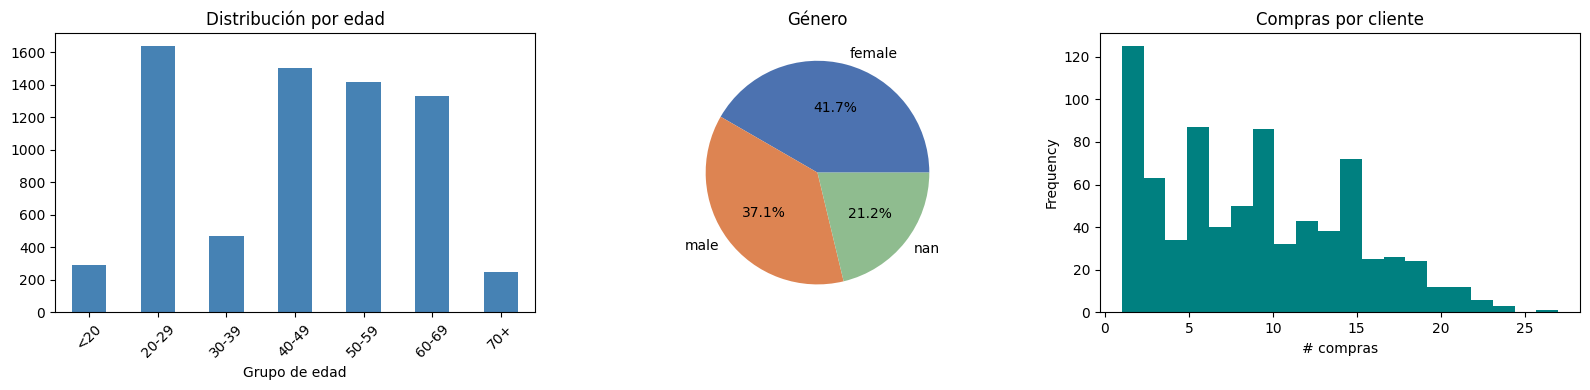

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Edad
train['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución por edad')
axes[0].set_xlabel('Grupo de edad')
axes[0].tick_params(axis='x', rotation=45)

# Género
train['customer_gender'].value_counts(dropna=False).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#8FBC8F'])
axes[1].set_title('Género')
axes[1].set_ylabel('')

# Compras por cliente
purchases_per_customer.plot(kind='hist', bins=20, ax=axes[2], color='teal')
axes[2].set_title('Compras por cliente')
axes[2].set_xlabel('# compras')

plt.tight_layout()
plt.show()